In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.explainability.shap_explainer import SHAPExplainer

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("All imports successful")

All imports successful


In [2]:
lr_model = joblib.load('../models/logistic_model.pkl')
scaler   = joblib.load('../models/scaler.pkl')

# Load the WoE transformed data
X_train = pd.read_csv('../data/processed/X_train_woe.csv', index_col=0)
X_test  = pd.read_csv('../data/processed/X_test_woe.csv',  index_col=0)
y_train = pd.read_csv('../data/processed/y_train.csv',     index_col=0).squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv',      index_col=0).squeeze()

feature_names = X_train.columns.tolist()

print(f"Model loaded  : {type(lr_model).__name__}")
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"Features      : {len(feature_names)}")

Model loaded  : LogisticRegression
X_train shape : (246008, 30)
X_test shape  : (61503, 30)
Features      : 30


In [3]:
explainer = SHAPExplainer(
    model         = lr_model,
    scaler        = scaler,
    feature_names = feature_names
)

# Fit on a sample of training data for speed
# 5000 rows is enough to get a stable background distribution
X_train_sample = X_train.sample(n=5000, random_state=42)

explainer.fit(X_train_sample)

Fitting SHAP explainer...
SHAP explainer fitted successfully
Expected value (base rate) : -0.3422


Bar plot saved to ../docs/shap_plots/shap_global_bar.png


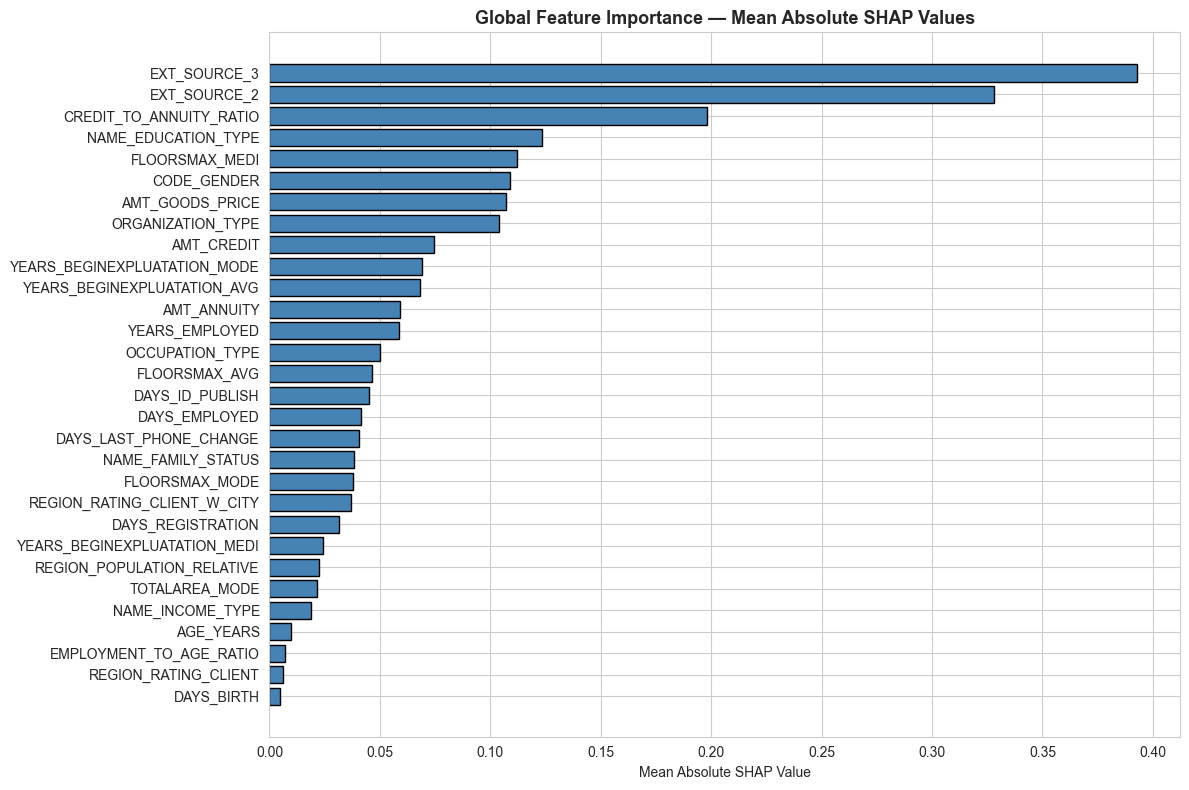

Beeswarm plot saved to ../docs/shap_plots/shap_global_beeswarm.png


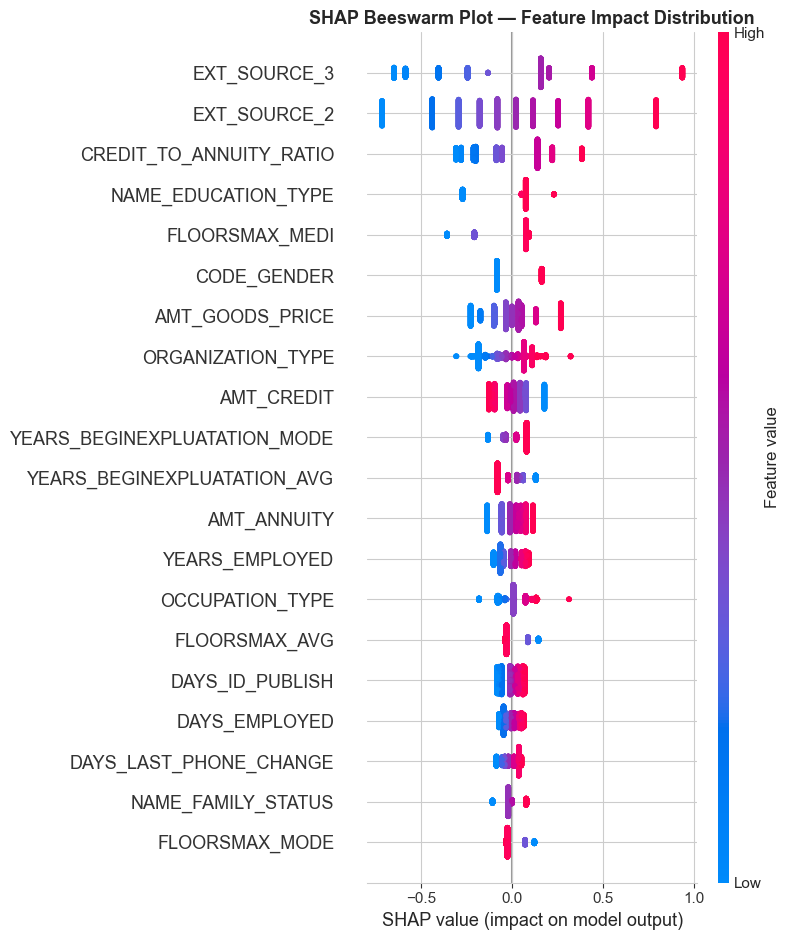

In [4]:
X_test_sample = X_test.sample(n=2000, random_state=42)

explainer.plot_global_importance(
    X_woe      = X_test_sample,
    save_path  = '../docs/shap_plots/shap_global.png'
)

In [5]:
repaid_idx       = y_test[y_test == 0].index[0]
repaid_applicant = X_test.loc[[repaid_idx]]

# Get explanation
explanation = explainer.explain_single_applicant(repaid_applicant)

print("=" * 65)
print("SHAP EXPLANATION — REPAID APPLICANT")
print("=" * 65)
print(f"\n{'Feature':<45} {'SHAP':>8}  Impact")
print("-" * 65)
for _, row in explanation.iterrows():
    print(f"  {row['Feature']:<43} {row['SHAP_Value']:>+8.4f}  {row['Impact']}")

print(f"\nBase rate (average default probability) : {explainer.explainer.expected_value:.4f}")
print(f"Sum of SHAP values                      : {explanation['SHAP_Value'].sum():.4f}")

SHAP EXPLANATION — REPAID APPLICANT

Feature                                           SHAP  Impact
-----------------------------------------------------------------
  CREDIT_TO_ANNUITY_RATIO                      -0.2807  decreases default risk
  NAME_EDUCATION_TYPE                          -0.2728  decreases default risk
  EXT_SOURCE_3                                 +0.2040  increases default risk
  AMT_GOODS_PRICE                              -0.1748  decreases default risk
  CODE_GENDER                                  +0.1632  increases default risk
  AMT_ANNUITY                                  +0.1150  increases default risk
  YEARS_EMPLOYED                               +0.0817  increases default risk
  EXT_SOURCE_2                                 -0.0809  decreases default risk
  YEARS_BEGINEXPLUATATION_AVG                  -0.0804  decreases default risk
  YEARS_BEGINEXPLUATATION_MODE                 +0.0801  increases default risk
  FLOORSMAX_MEDI                            

In [6]:
default_idx       = y_test[y_test == 1].index[0]
default_applicant = X_test.loc[[default_idx]]

# Get explanation
explanation_default = explainer.explain_single_applicant(default_applicant)

print("=" * 65)
print("SHAP EXPLANATION — DEFAULTED APPLICANT")
print("=" * 65)
print(f"\n{'Feature':<45} {'SHAP':>8}  Impact")
print("-" * 65)
for _, row in explanation_default.iterrows():
    print(f"  {row['Feature']:<43} {row['SHAP_Value']:>+8.4f}  {row['Impact']}")

print(f"\nBase rate (average default probability) : {explainer.explainer.expected_value:.4f}")
print(f"Sum of SHAP values                      : {explanation_default['SHAP_Value'].sum():.4f}")

SHAP EXPLANATION — DEFAULTED APPLICANT

Feature                                           SHAP  Impact
-----------------------------------------------------------------
  EXT_SOURCE_3                                 +0.4399  increases default risk
  CREDIT_TO_ANNUITY_RATIO                      -0.2005  decreases default risk
  ORGANIZATION_TYPE                            -0.1853  decreases default risk
  EXT_SOURCE_2                                 -0.1789  decreases default risk
  NAME_FAMILY_STATUS                           -0.1080  decreases default risk
  CODE_GENDER                                  -0.0841  decreases default risk
  YEARS_BEGINEXPLUATATION_AVG                  -0.0804  decreases default risk
  YEARS_BEGINEXPLUATATION_MODE                 +0.0801  increases default risk
  FLOORSMAX_MEDI                               +0.0762  increases default risk
  NAME_EDUCATION_TYPE                          +0.0752  increases default risk
  YEARS_EMPLOYED                         

In [7]:
import os
os.makedirs('../docs/shap_plots', exist_ok=True)

# Save the explainer
explainer.save('../models/shap_explainer.pkl')

print("=" * 60)
print("SHAP EXPLAINABILITY SUMMARY")
print("=" * 60)
print(f"""
WHAT SHAP DOES
---------------
- Assigns each feature a value showing how much it pushed
  the prediction away from the average prediction
- Positive SHAP = increases default risk
- Negative SHAP = decreases default risk
- Base rate (expected value) = {explainer.explainer.expected_value:.4f}

KEY FINDINGS
-------------
- EXT_SOURCE_3 is the most impactful feature for both
  repaid and defaulted applicants
- CREDIT_TO_ANNUITY_RATIO and NAME_EDUCATION_TYPE are
  strong negative drivers (reduce default risk when favorable)
- Results are consistent with IV analysis from Phase 5

WHAT IS SAVED
--------------
- models/shap_explainer.pkl           — fitted SHAP explainer
- docs/shap_plots/shap_global_bar.png      — global importance bar plot
- docs/shap_plots/shap_global_beeswarm.png — beeswarm plot
""")
print("=" * 60)
print("SHAP COMPLETE — Ready for Phase 9 FastAPI")
print("=" * 60)

SHAP explainer saved to ../models/shap_explainer.pkl
SHAP EXPLAINABILITY SUMMARY

WHAT SHAP DOES
---------------
- Assigns each feature a value showing how much it pushed
  the prediction away from the average prediction
- Positive SHAP = increases default risk
- Negative SHAP = decreases default risk
- Base rate (expected value) = -0.3422

KEY FINDINGS
-------------
- EXT_SOURCE_3 is the most impactful feature for both
  repaid and defaulted applicants
- CREDIT_TO_ANNUITY_RATIO and NAME_EDUCATION_TYPE are
  strong negative drivers (reduce default risk when favorable)
- Results are consistent with IV analysis from Phase 5

WHAT IS SAVED
--------------
- models/shap_explainer.pkl           — fitted SHAP explainer
- docs/shap_plots/shap_global_bar.png      — global importance bar plot
- docs/shap_plots/shap_global_beeswarm.png — beeswarm plot

SHAP COMPLETE — Ready for Phase 9 FastAPI
